<a href="https://colab.research.google.com/github/d4nye1/flight_on_time_mvp_H12-25-L-Equipo33/blob/feature%2Fdata-science/data-science/DataScience_seleccion-features.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install gdown -q

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from scipy.stats import chi2_contingency
import gdown

## **Selección y entrenamiento de características**

Se alojó la base de datos limpia proveniente del notebook anterior (DataScience - Limpieza y EDA de datos) en un archivo parquet en drive. La misma base se lee para su uso en este notebook.

El propósito del notebook es el de determinar las características o entradas necesarias y relevantes para el modelo, con la finalidad de elegir las más adecuadas para una buena clasificación.

In [3]:
url = 'https://drive.google.com/file/d/1uCFvcPHO-bchVYWDDtfc7R1Lzr1rSGCI/view?usp=sharing'
url = 'https://drive.google.com/uc?id=' + url.split('/')[-2]

output = 'df_clean_modeling.parquet'
gdown.download(url, output, quiet=False)

Downloading...
From: https://drive.google.com/uc?id=1uCFvcPHO-bchVYWDDtfc7R1Lzr1rSGCI
To: /content/df_clean_modeling.parquet
100%|██████████| 54.3M/54.3M [00:00<00:00, 129MB/s]


'df_clean_modeling.parquet'

In [4]:
cleaned_database = pd.read_parquet("df_clean_modeling.parquet")

In [5]:
cleaned_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965266 entries, 0 to 6965265
Data columns (total 14 columns):
 #   Column              Dtype  
---  ------              -----  
 0   mes                 int64  
 1   dia_mes             int64  
 2   dia_semana          int64  
 3   fin_de_semana       int64  
 4   hora_salida         int64  
 5   minuto_salida       int64  
 6   distancia_millas    float64
 7   tiempo_programado   float64
 8   aerolinea           object 
 9   aeropuerto_origen   object 
 10  aeropuerto_destino  object 
 11  estado_origen       object 
 12  estado_destino      object 
 13  vuelo_retrasado     int64  
dtypes: float64(2), int64(7), object(5)
memory usage: 744.0+ MB


### **Codificación de variables temporales**

Se codificaron las variables temporales  (mes, dia semana, hora salida, minuto salida) para reflejar el carácter temporal de las variables. Si se codificaran como variables enteras, existiría un salto, por ejemplo, entre la última hora del día (23) y la primera (0), perdiéndose el carácter continuo, cíclico, mientras que al aplicar funciones senoidales o cosenoidales, se retiene dicha característica (estas funciones se repiten cíclicamente) y en este caso, la hora 23 está más cerca de la hora 0, que de la hora 21.

Esta codificación será de utilidad al entrenar el modelo de Machine Learning, para lograr que el modelo "observe" y sea posible para él visualizar dichas relaciones temporales en estas características.



In [6]:
def encode_cycle(data, col):

    max = data[col].max()
    data[col + '_sin'] = np.sin( 2 * np.pi * data[col] / max)
    data[col + '_cos'] = np.cos( 2 * np.pi * data[col] / max)

    return data

In [7]:
cyclical_columns = ['mes', 'dia_mes', 'dia_semana', 'hora_salida', 'minuto_salida']

for column in cyclical_columns:
  df_clean_modelo = encode_cycle(cleaned_database, column)

Para ejemplificar dicho resultado de la codificación, se imprimieron los resultados con la finalidad de observar los valores únicos en las columnas temporales de la base de datos. Al observar círculos en las gráficas, se nota que el carácter cíclico de las fechas, o sus componentes, es respetado.

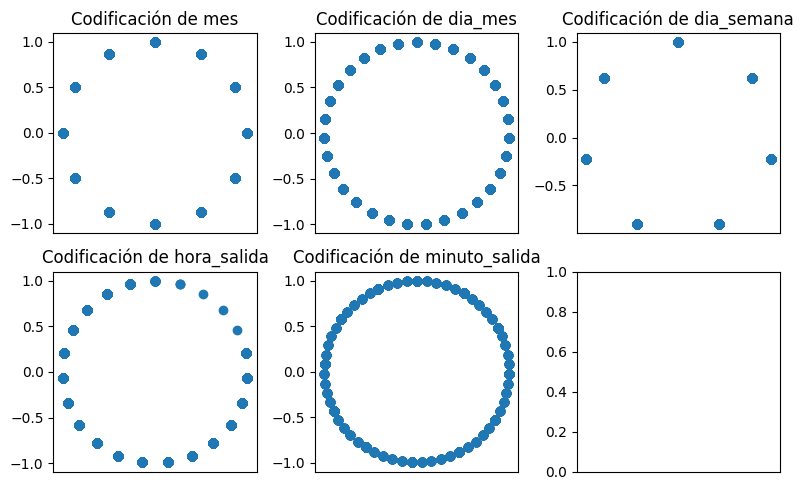

In [8]:
fig, axs = plt.subplots(2, 3, figsize = (8,5) )
sample = cleaned_database.sample(5000, random_state=7)

for i, ax in enumerate(axs.flatten()):
  if( i < len(cyclical_columns)):
    ax.scatter(sample[cyclical_columns[i] + '_sin'], sample[cyclical_columns[i] + '_cos'])
    ax.set_title(f"Codificación de {cyclical_columns[i]}")
  ax.set_xticks([])

plt.tight_layout()
plt.show()

In [9]:
columns_time = ['mes','dia_mes','dia_semana','hora_salida', 'minuto_salida']

for column in columns_time:
  try:
    cleaned_database.drop(columns = column, inplace = True)
  except:
    pass

### **Codificación variables categóricas**

Posteriormente se realiza el conteo de valores únicos de las variables categóricas presentes con la finalidad de definir una estrategia de codificación viable. La codificación es una estrategia que ayuda a cuantificar las categorías de forma que sea entendible para el modelo. Por la cantidad de categorías, se decide que la codificación One Hot no es viable, ya que produciría un aumento horizontal innecesariamente grande de características o featues y se opta ya sea por label encoding, ordinal encoding o target encoding que codifican las categorías sobre una misma columna.

In [10]:
categorical_columns = ['aerolinea', 'aeropuerto_origen', 'estado_origen', 'aeropuerto_destino', 'estado_destino']

print("Valores únicos de columnas categóricas")
for column in categorical_columns:
  print(f"{column}: {cleaned_database[column].nunique()}")

Valores únicos de columnas categóricas
aerolinea: 15
aeropuerto_origen: 348
estado_origen: 52
aeropuerto_destino: 348
estado_destino: 52


La mezcla de distintas variables categoricas para producir resultados únicos como categorías previo a codificar tampoco es viable por el tamaño de datos únicos, por lo que se descarta como posible feature elaborada a partir de los datos.

In [11]:
cleaned_database['aeropuerto origen-destino'] = cleaned_database['aeropuerto_origen'] + cleaned_database['aeropuerto_destino']
cleaned_database['aeropuerto origen-destino'].nunique()

6792

In [12]:
cleaned_database['estado origen-destino'] = cleaned_database['estado_origen'] + cleaned_database['estado_destino']
cleaned_database['estado origen-destino'].nunique()

1376

**Resumen de sección.
Cantidad de categorías en:**

1) aerolínea : 15

2) aeropuerto de origen (AO) : 348

3) aeropuerto de destino (AD) : 348

4) estado de origen (SO) : 52

5) estado de destino (SD) : 52

6) AO + AD : 6792 posibles combinaciones

7) SO + SD : 1376 posibles combinaciones

In [13]:
!pip install category_encoders -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.9/85.9 kB 3.8 MB/s eta 0:00:00


In [14]:
import category_encoders as ce

In [15]:
columns_to_drop = ['aeropuerto origen-destino', 'estado origen-destino']

for column in columns_to_drop:
  try:
    cleaned_database.drop(columns = column, inplace = True)
  except:
    pass

Se recodificó a booleano la variable fin de semana ya que para la estandarización llevada a cabo en pasos posteriores no tiene aplicación dejarla como variable entera y escalarla más allá de su valor booleano intrínseco.

In [16]:
cleaned_database['fin_de_semana'] = cleaned_database['fin_de_semana'].astype(bool)

In [17]:
cleaned_database.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6965266 entries, 0 to 6965265
Data columns (total 19 columns):
 #   Column              Dtype  
---  ------              -----  
 0   fin_de_semana       bool   
 1   distancia_millas    float64
 2   tiempo_programado   float64
 3   aerolinea           object 
 4   aeropuerto_origen   object 
 5   aeropuerto_destino  object 
 6   estado_origen       object 
 7   estado_destino      object 
 8   vuelo_retrasado     int64  
 9   mes_sin             float64
 10  mes_cos             float64
 11  dia_mes_sin         float64
 12  dia_mes_cos         float64
 13  dia_semana_sin      float64
 14  dia_semana_cos      float64
 15  hora_salida_sin     float64
 16  hora_salida_cos     float64
 17  minuto_salida_sin   float64
 18  minuto_salida_cos   float64
dtypes: bool(1), float64(12), int64(1), object(5)
memory usage: 963.2+ MB


### **Correlación e importancia entre variables**

Durante esta sección se elaboraron las matrices de correlación de variables numéricas, así como la prueba de Cramer para variables categóricas. En relación con la variable a clasificar (vuelo_retrasado), las variables en la matriz de correlación tendrán un valor cercano a 1 si la relación con la variable a clasificar es muy alta y creciente en ambos sentidos (si un vuelo se retrasa, dicha variable aumenta), -1 en el caso contrario (si un vuelo no se retrasa, la variable disminuye) y un valor cercano a 0 en caso de que la relación entre ambas variables sea nula. En el caso de la prueba de Cramer, solamente puede tomar valores positivos, y entre más positivo sea dicho valor, mayor es el grado de relación o asociación entre variables.

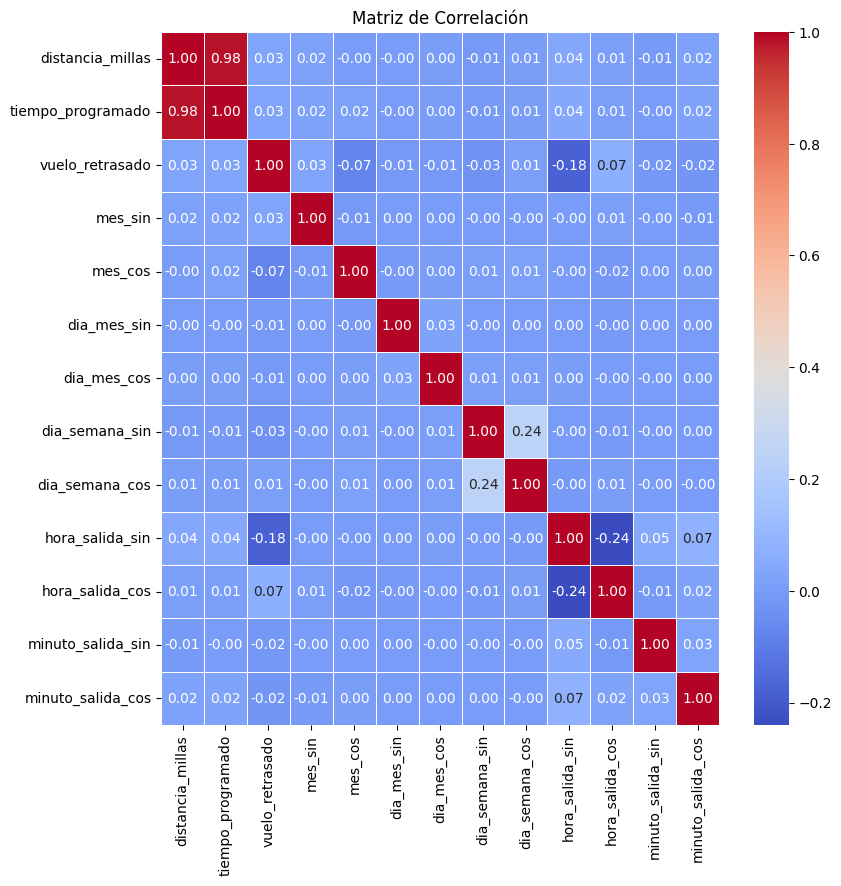

In [18]:
num_cols = cleaned_database.select_dtypes(include=['number']).columns
df_numeric = cleaned_database[num_cols]

matrix = df_numeric.corr(method = 'spearman')

plt.figure(figsize=(9,9))
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Matriz de Correlación")
plt.show()

De acuerdo con lo encontrado en la matriz de correlación, y en línea con lo encontrado durante el análisis de la base de datos previa, se encuentra que las variables con mayor relación para determinar si un vuelo se retrasa o no son:

1) Hora de salida
2) Mes de vuelo
3) Día de la semana
4) Distancia recorrida y tiempo programado de vuelo

Sin embargo, se hace notar al equipo que por sí mismas, dichas variables se consideran insuficientes para otorgar una predicción de calidad respecto a si un vuelo es retrasado o no, por lo que utilizar muchas de ellas o pocas, no tiene un efecto significativo en la mejora de la predicción. Sin embargo, se seleccionarán las más importantes al ser las variables que no presentan fuga de información, es decir, que no otorgan información del evento (vuelo) una vez ocurrido, y que se conocen previo al despegue.

In [19]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape)-1)))

In [20]:
results = {col: cramers_v(cleaned_database[col], cleaned_database['vuelo_retrasado']) for col in categorical_columns}
results_series = pd.Series(results).sort_values(ascending=False)

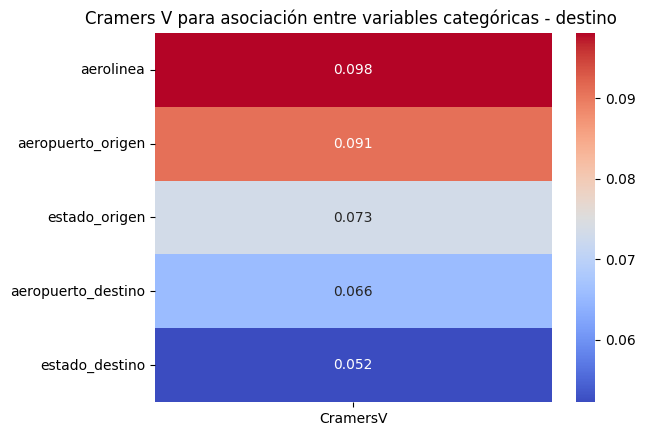

In [21]:
sns.heatmap(pd.DataFrame(results_series, columns=['CramersV']), annot=True, cmap='coolwarm')
plt.title('Cramers V para asociación entre variables categóricas - destino ')
plt.show()

Se calculó la asociación entre las variables mediante la prueba de Cramers V.

En la visualización de las variables categóricas con la variable destino, se observa que las categorías con mayor relación con la etiqueta a predecir son la aerolínea (como se descubrió en el análisis previo de datos), el aeropuerto de origen y el estado de origen.

Nuevamente, se considera que dichas relaciones son relaciones débiles, y por sí solas son de nuevo insuficientes para entrenar un modelo de gran poder predictivo. Se utilizarán las que aporten mayor cantidad de información para el modelo.

### **Resumen**

Al final de dicho análisis, se determinó que:
1) Es necesaria la codificación de variables temporales como variables cíclicas

2) La hora de salida, el mes de vuelo, el día de la semana, la distancia a recorrer y el tiempo programado de vuelo, son las variables numéricas que aportan mayor cantidad de información al modelo. Sin embargo, como el tiempo programado de vuelo puede ser variable, y al ser la distancia una variable fija entre aeropuertos, se decidió utilizar solamente la distancia entre dichas variables, además de las antes mencionadas.

3) La aerolínea, el aeropuerto de origen y el estado de origen son las variables que aportan mayor información como variables categóricas. Para mantener una consistencia y un orden en las predicciones, se decidió utilizar la aerolínea, aeropuerto de origen y aeropuerto de destino, que si bien, aporta ligeramente menos información que el estado de origen, es consistente con el aeropuerto de origen y el modelo puede utilizar su relación para realizar combinaciones y descubrir patrones ocultos de retraso recurrentes entre aeropuertos.

4) Finalmente, a petición del equipo de backend, y a falta de una base de datos para consultar los datos completos que alimentarán al modelo en este punto, dentro del pipeline para el desarrollo del modelo se calcularán las columnas temporales (recibiendo solamente la fecha como variable, es decir, formato datetime) así como las distancias entre aeropuertos, al ser este un dato no disponible directamente para el cliente o desconocido para él.